<div style="font-size: 0.6em">

# Importing packages and libraries

</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import PatchCollection 
import seaborn as sns
from IPython.display import display, HTML
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles
from cycler import cycler

# Import the custom modules  
import hts.core as hts
import hts.variables as hts_var

display(HTML(data="""
<style>
    div#notebook-container    { height: 100%; }
    div#menubar-container     { height: 100%; }
    div#maintoolbar-container { height: 110%; }
    <img src="image.JPG" alt="Drawing" style="height: 200px;"/>
</style>
"""))

# Adjust the display for being able to observe all rows and columns of 
# the dataframe.
pd.set_option('display.max_columns', None) # Displaying all columns
pd.set_option('display.max_rows', None) # Displaying all columns

<div style="font-size: 0.6em">

# Import and prepare data 

</div>

In [ ]:
import_dir = r"YOUR_IMPORT_DIRECTORY_HERE"
df_Control = pd.read_csv(import_dir + "/Controls.csv")
df_Sample = pd.read_csv(import_dir + "/Samples.csv")

In [ ]:
# Sort the cells. This is needed for line graph to be seen az a ascending line, instead of random lines. 
df_Control.sort_values(
    by='EV-uptake_Normalized_by_mean', 
    ascending=True, 
    inplace=True
)
df_Sample.sort_values(
    by='EV-uptake_Normalized_by_mean', 
    ascending=True, 
    inplace=True
)

In [ ]:
# Check the mean and standard deviation of the controls
control_mean = df_Control['EV-uptake_Normalized_by_mean'].mean()
control_std = df_Control['EV-uptake_Normalized_by_mean'].std()
mean_plus_2SD_control_EVsPerArea_Normalized = control_mean + 2*(control_std)
mean_minus_2SD_control_EVsPerArea_Normalized =  control_mean - 2*(control_std)
print("Control mean: ", control_mean)
print("Control std: ", control_std)
print("Control mean + 2*std: ", mean_plus_2SD_control_EVsPerArea_Normalized)
print("Control mean - 2*std: ", mean_minus_2SD_control_EVsPerArea_Normalized)

Control mean:  0.038644386186536726
Control std:  0.008228466412639008
Control mean + 2*std:  0.05510131901181474
Control mean - 2*std:  0.02218745336125871


<div style="font-size: 0.6em">

# EV-uptake range using line graph

</div>

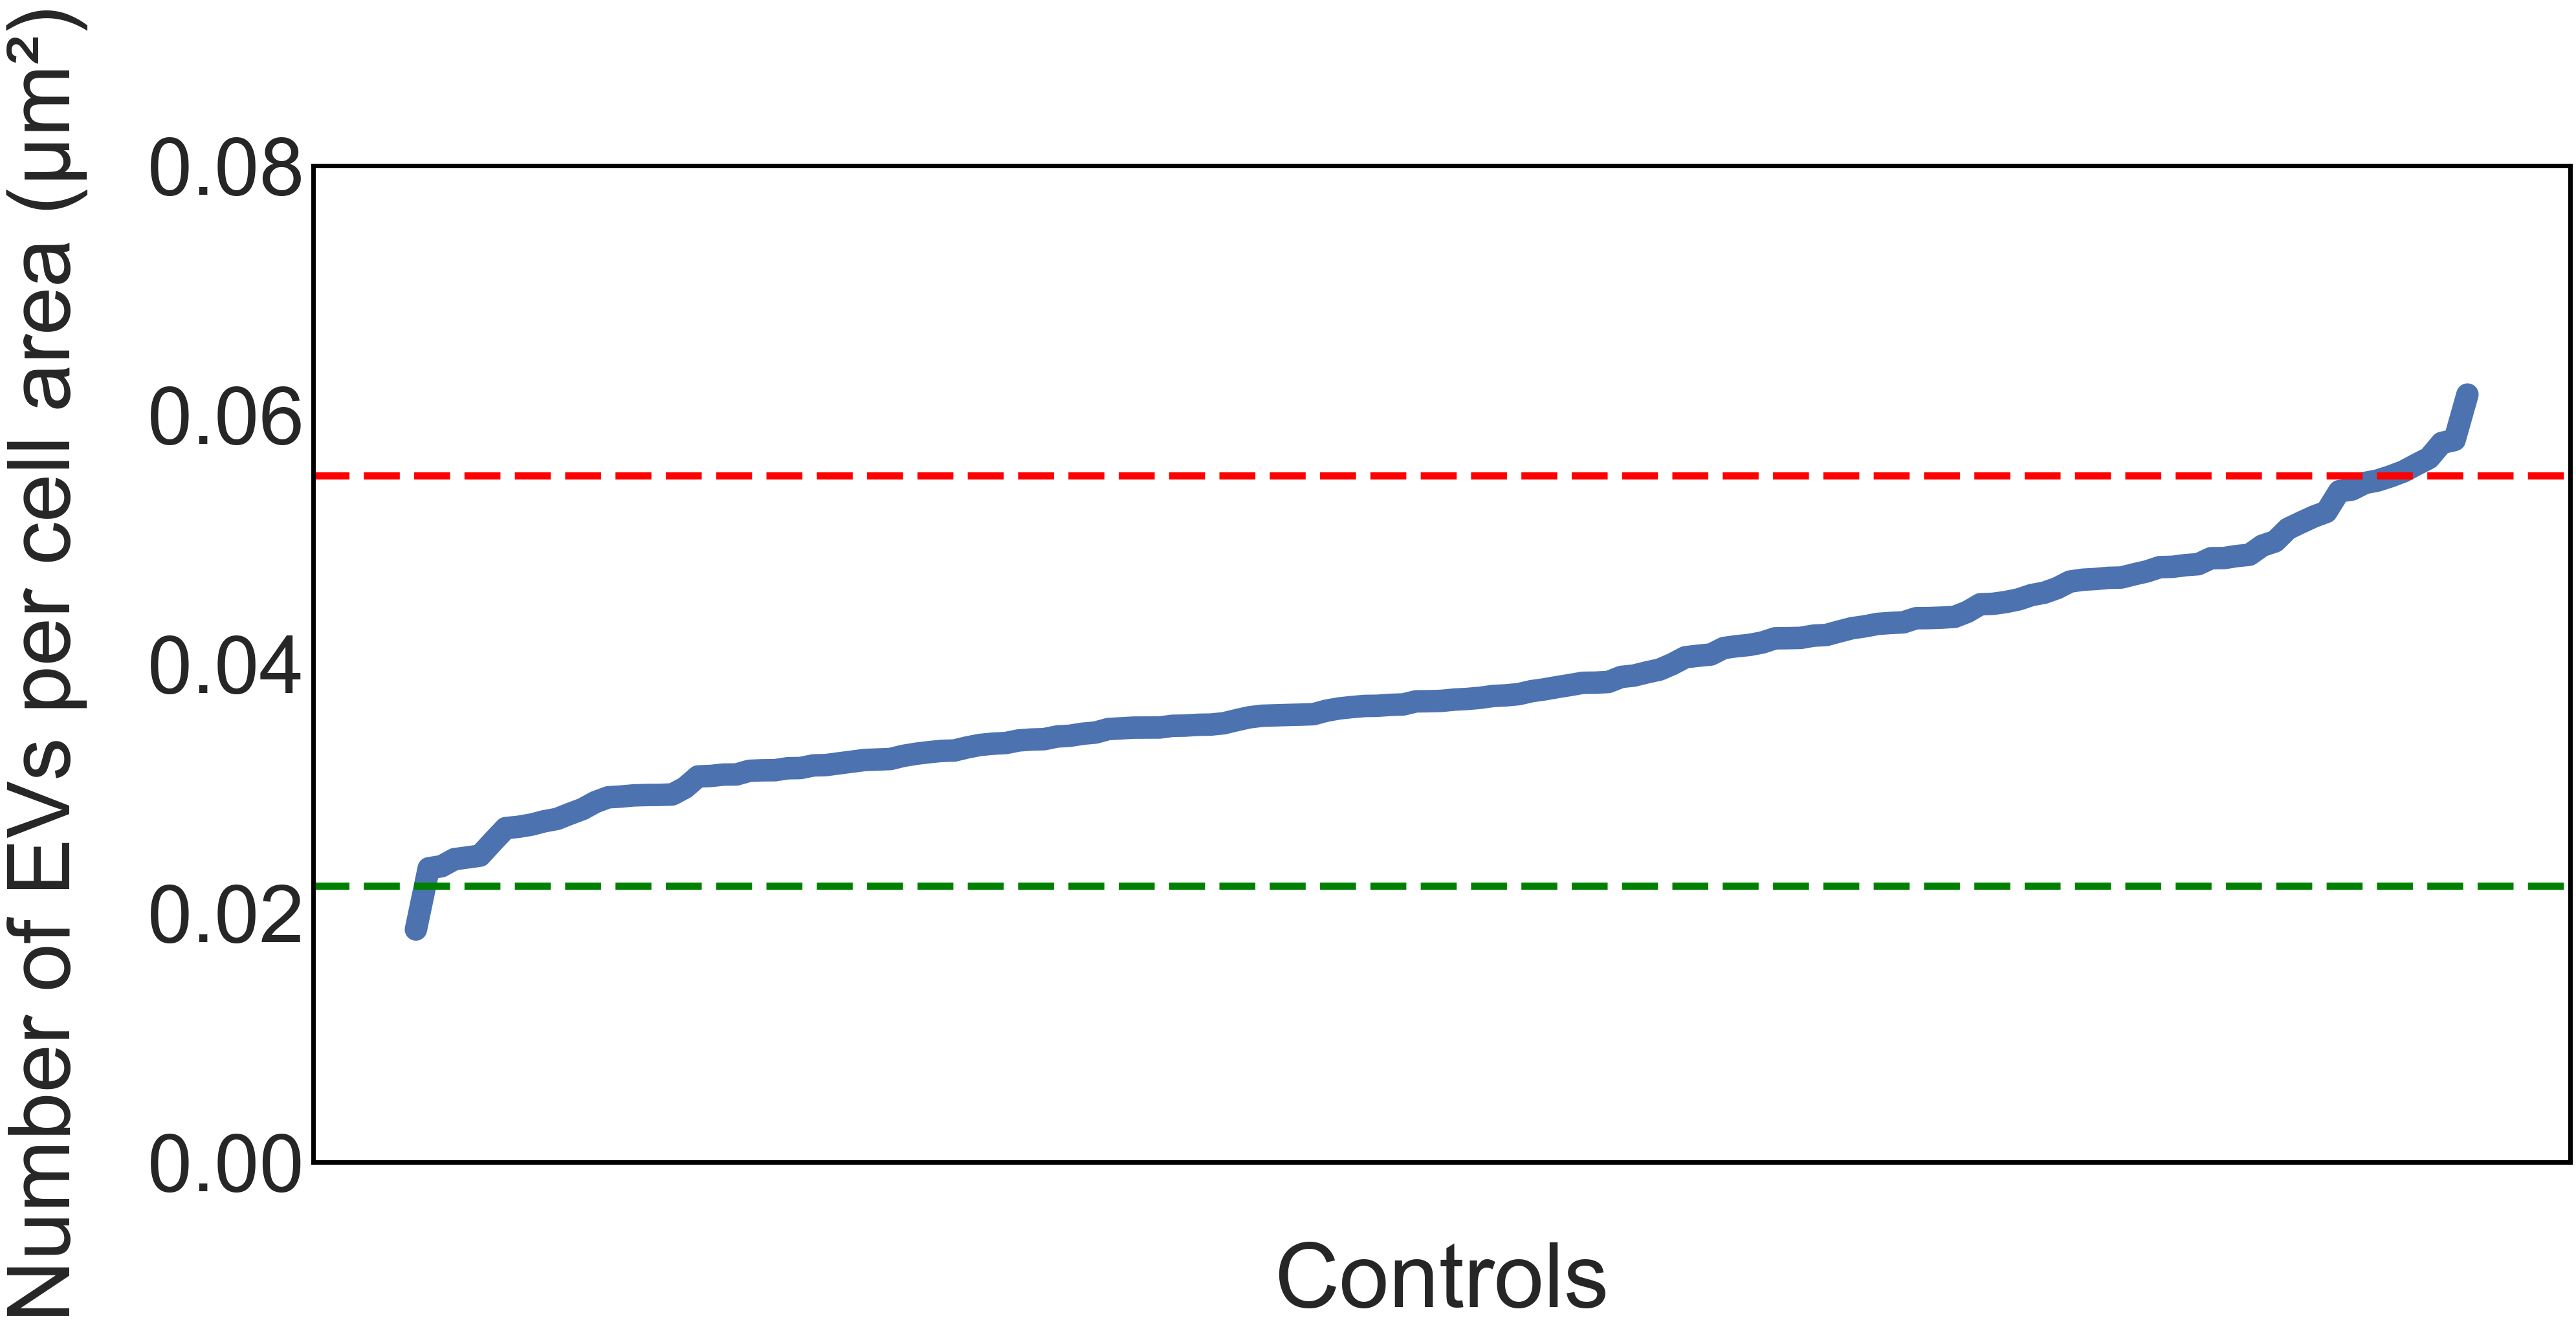

In [ ]:
"""Controls_Line graph"""

# set a flag for saving the figure, if needed.
save_fig = False

plt.figure(figsize=(45, 20))
sns.set(font_scale = 8)
g= sns.lineplot(
    x='Plate format', 
    y='EV-uptake_Normalized_by_mean', 
    data=df_Control, 
    estimator=None, 
    errorbar=None, 
    sort=False, 
    linewidth=25
)

# Change the color of the background  
g.patch.set_facecolor('white') 

# Add spine lines around the graph and change their color and thickness.
g.spines[['top', "bottom", "right", "left"]].set_color('black') 
[x.set_linewidth(5) for x in g.spines.values()]     
g.set(xlabel='Controls', ylabel='Number of EVs per cell area (µm²)')
g.set(ylim=(0, 0.08), yticks=[0, 0.02, 0.04, 0.06, 0.08])
plt.yticks(fontsize=90)
plt.xticks(ticks=[])
plt.xlabel('Controls', fontsize=100)

# change the distance of the label from the x and y axes
g.yaxis.set_label_coords(-0.10, 0.5)  
g.xaxis.set_label_coords(0.5, -0.08)  

# Change the size of the labels of x and y axes and the title, if needed. 
# plt.xlabel('Controls', fontsize=140) 
# plt.ylabel('EV-uptake', fontsize=140)
# plt.title("EV-uptake_Controls, size=150)

# Draw a line for mean +/- 2SD control
plt.axhline(
    y=mean_plus_2SD_control_EVsPerArea_Normalized, 
    color='red', 
    linewidth=8, 
    dashes=(5, 2)
) 
plt.axhline(
    y=mean_minus_2SD_control_EVsPerArea_Normalized, 
    color='green', 
    linewidth=8, 
    dashes=(5, 2)
) 

# Control the pad, which is the distance of the title from the graph.
g.set_title("", pad=100, fontsize=120) 

img_export_dir = r"YOUR_EXPORT_DIRECTORY_HERE"

if save_fig:
    # Save the image in .svg or .png format. 
    plt.savefig(
        fname= img_export_dir + "/NAME_OF_THE_FIGURE.svg", 
        bbox_inches='tight', 
        pad_inches=2.5
        # dpi=300 # if save as .png
    ) 

    plt.close()

else:
    plt.show()

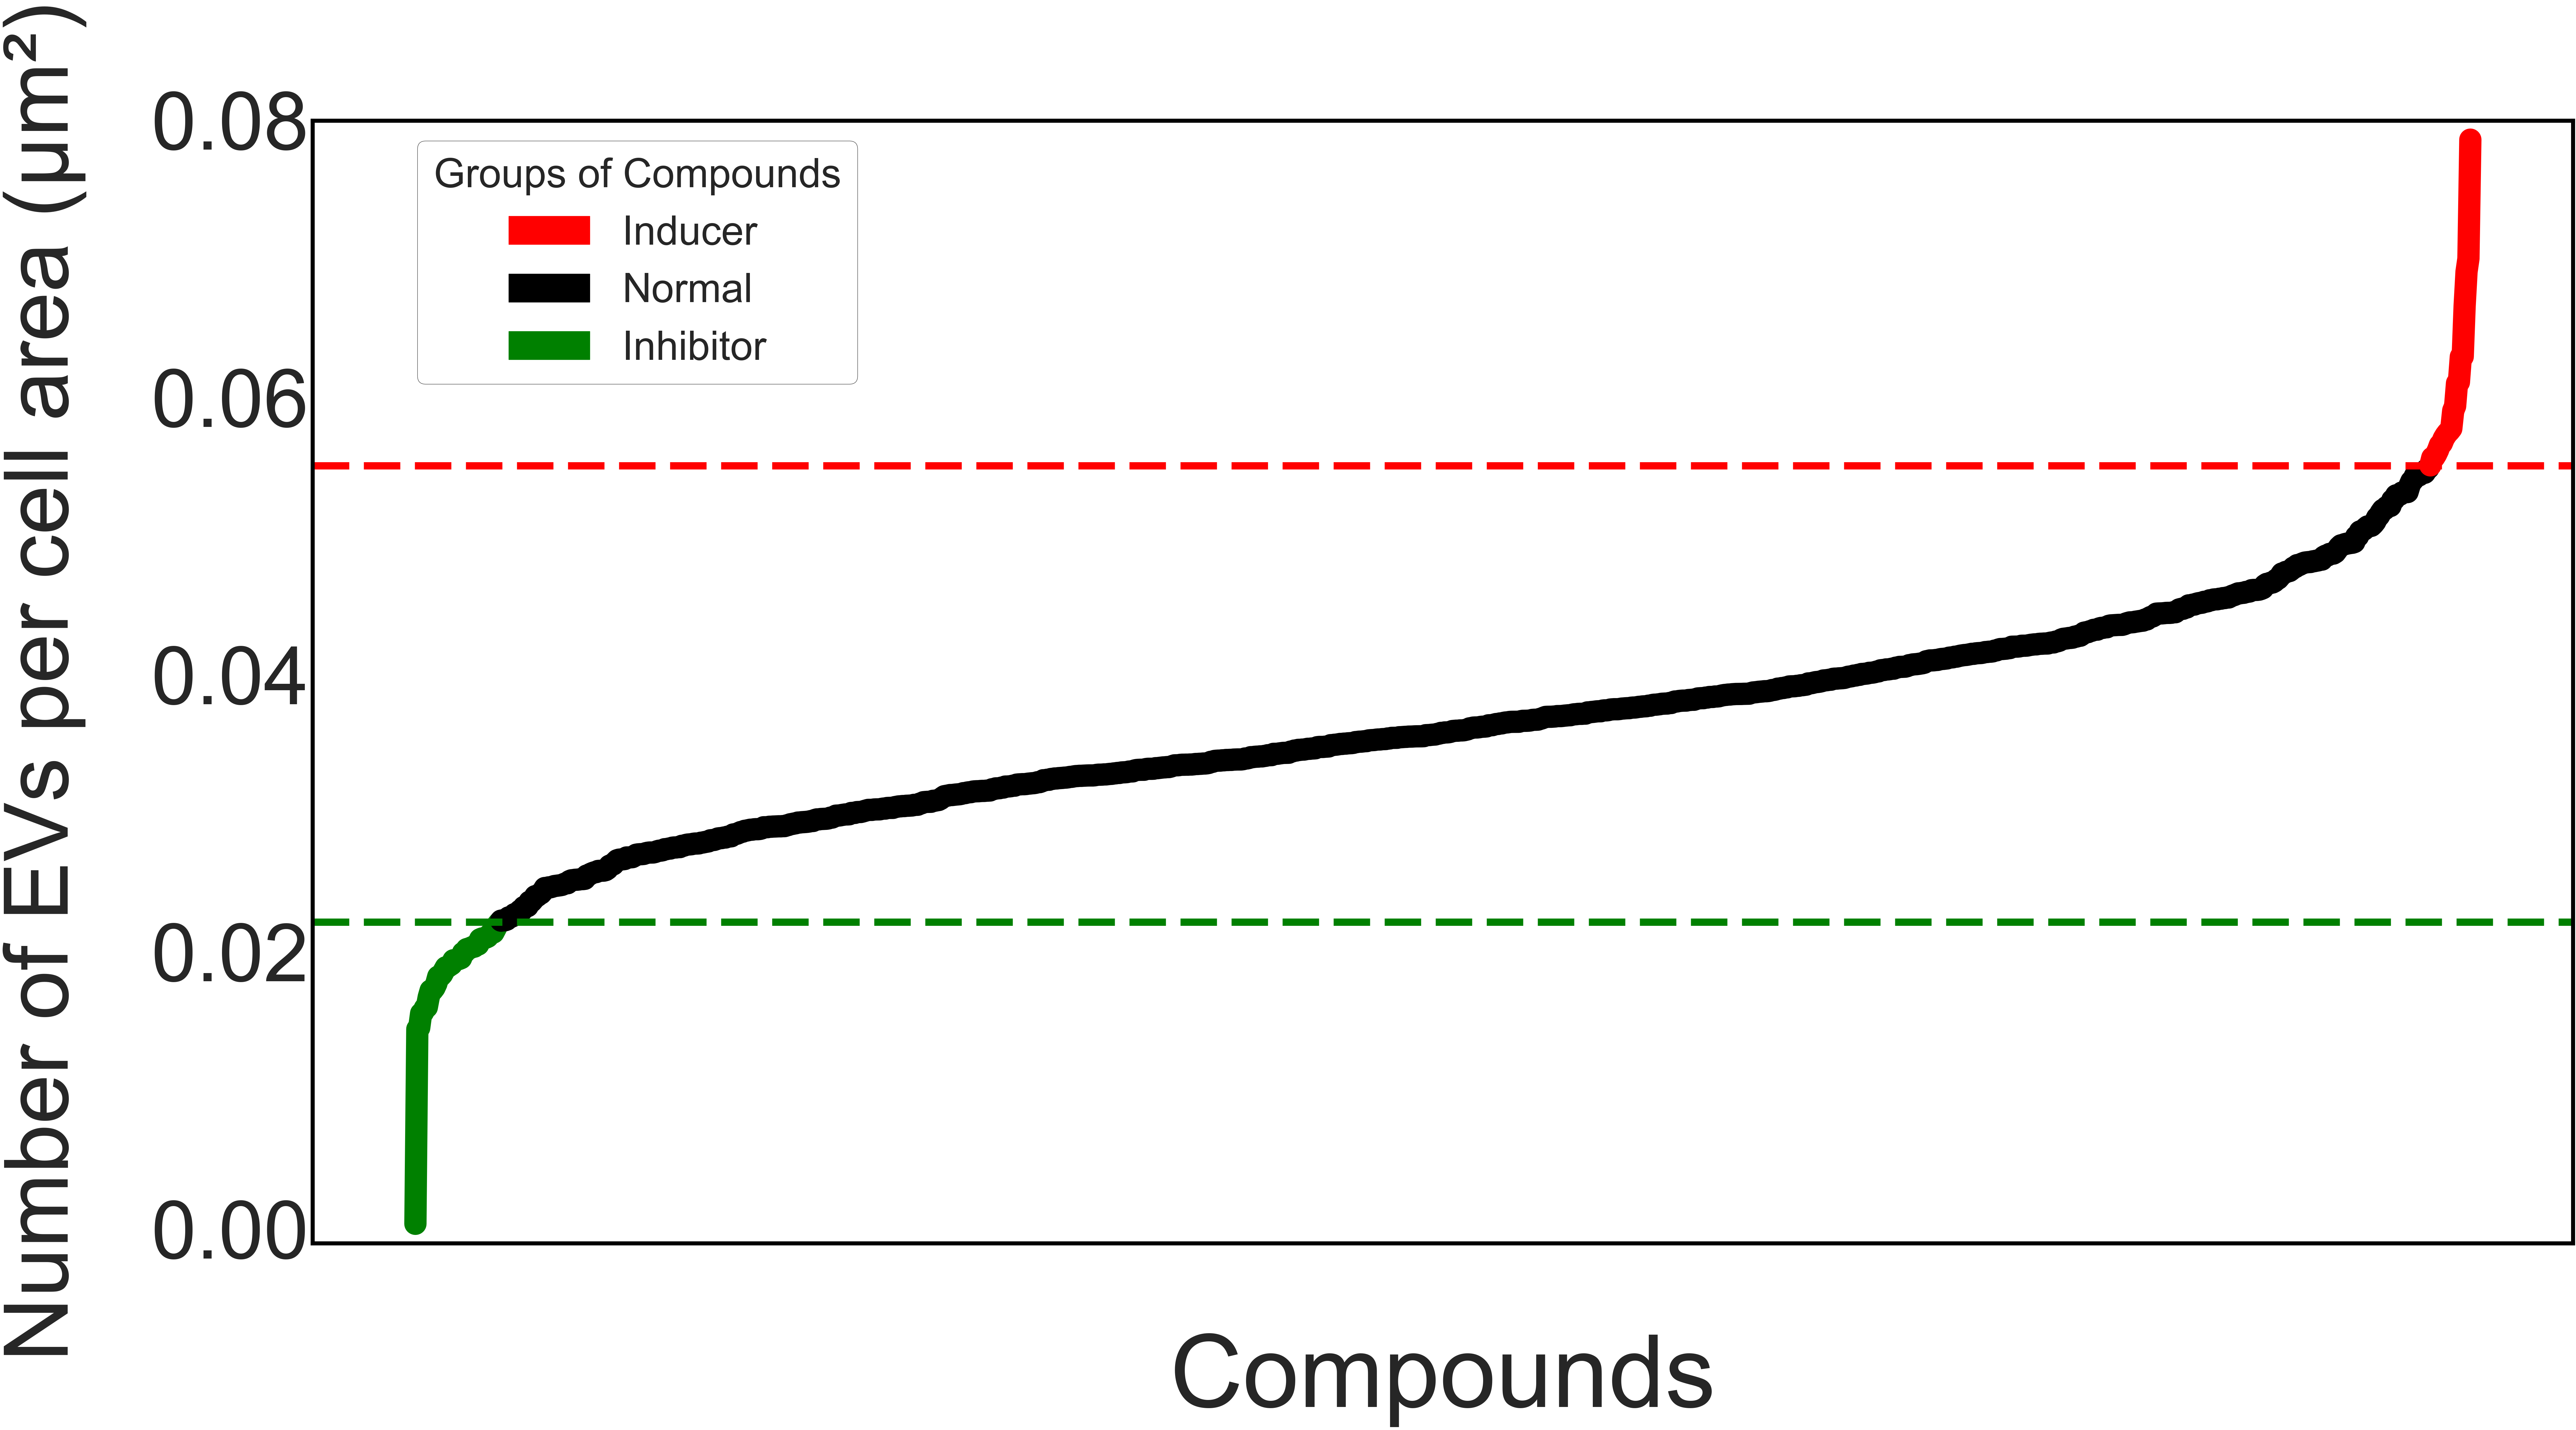

In [ ]:
"""Samples_Line graph"""

# set a flag for saving the figure, if needed.
save_fig = False

plt.figure(figsize=(100, 50))
sns.set(font_scale = 10)
color_map = {'Inhibitors':'green','Normal':'black', 'Inducers': 'red'}
g= sns.lineplot(
    x='Plate format',
    y='EV-uptake_Normalized_by_mean', 
    data=df_Sample, 
    hue="Category_by_2SD", 
    palette=color_map, 
    estimator=None, 
    errorbar=None, 
    sort=False, 
    linewidth=55
)

# Change the color of the background  
g.patch.set_facecolor('white') 

# Add spine lines around the graph and change their color and thickness.
g.spines[['top', "bottom", "right", "left"]].set_color('black') 
[x.set_linewidth(10) for x in g.spines.values()] 

# Set the x and y ticks, labels
g.set(xlabel='Controls', ylabel='Number of EVs per cell area (µm²)')
g.set(ylim=(-0.001, 0.08), yticks=[0, 0.02, 0.04, 0.06, 0.08])
plt.yticks(fontsize=200)
plt.xticks(ticks=[])
plt.xlabel('Compounds', fontsize=250)
plt.ylabel('Number of EVs per cell area (µm²)', fontsize=220)

# change the distance of the label from the x and y axes
g.yaxis.set_label_coords(-0.10, 0.5)  
g.xaxis.set_label_coords(0.5, -0.08)  

 # The line for mean control mean +/- 2SD control
plt.axhline(
    y=mean_plus_2SD_control_EVsPerArea_Normalized, 
    color='red', 
    linewidth=18, 
    dashes=(5, 2)
)
plt.axhline(
    y=mean_minus_2SD_control_EVsPerArea_Normalized, 
    color='green', 
    linewidth=18, 
    dashes=(5, 2)
) 

# Set the pad, which is the distance of the title from the graph, if needed.
#g.set_title(
# "TITLE", 
# pad=100, 
# fontsize=200
#) 

# Add lines to show the categorization of the compounds.
red = mpatches.Patch(color='red', label='Inducer')
black = mpatches.Patch(color='black', label='Normal')
green = mpatches.Patch(color='green', label='Inhibitor')

# Add the patches to the legend:
g.legend(
    handles=[red, black, green], 
    title="Groups of Compounds", 
    fontsize=100, 
    title_fontsize=100, 
    bbox_to_anchor=(0.25, 1), 
    borderaxespad=0.5, 
    facecolor="white", 
    edgecolor= "black"
)  

# Modify the legend, if needed.
# legend = g.legend(prop={'size': 200})
# for legobj in legend.legendHandles:
#     legobj.set_linewidth(50)

img_export_dir = r"YOUR_EXPORT_DIRECTORY_HERE"

if save_fig:
    # Save the image in .svg or .png format. 
    plt.savefig(
        fname= img_export_dir + "/NAME_OF_FIG.svg", 
        bbox_inches='tight', 
        pad_inches=2.5
    ) 
    plt.close()

else:
    plt.show()

<div style="font-size: 0.6em">

# Cell count distribution using histogram

</div>

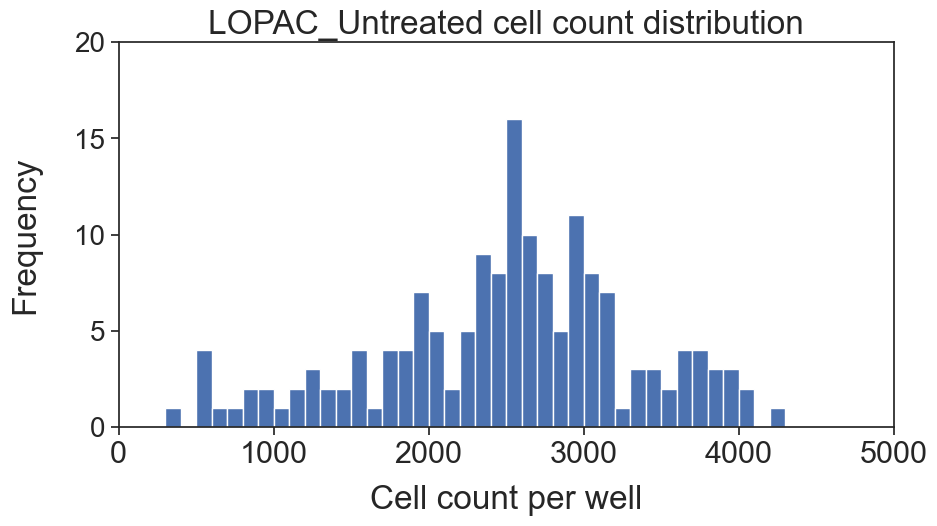

In [ ]:
"""Cell count distribution of control group"""

# set a flag for saving the figure, if needed.
save_fig = False

plt.figure(figsize=(10, 5))
sns.set(font_scale=2)
sns.set_style("ticks")
g = sns.histplot(
    data=df_Control,
    x="Nuclei in confirmed total cell region - Number of Objects",
    binrange=(0.0, 5000),
    bins=50,
    kde=False,
    alpha=1
)  # binrange=(0.0, 0.015),  

# distance of label from x and y axes
g.xaxis.set_label_coords(0.5, -0.15)
g.yaxis.set_label_coords(-0.10, 0.5) 


# Define the limits of x and y axes. Start with (0, 0) at the bottom left.
plt.xlim(0, 5000) 
plt.ylim(0, 20)

# Modify the values and size of ticks of y axis 
plt.yticks(fontsize=20)
# g.set(yticks=[5, 10, 15, 20, 25, 30, 35, 40])

# Add a label to x and y axes and a title to the graph. Change the sizes,
# if needed.  
plt.xlabel('Cell count per well', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.title("LOPAC_Untreated cell count distribution")

if save_fig:

    # Define the export directory for the image.
    img_export_dir = (
    r"YOUR_EXPORT_DIRECTORY_HERE"
    )

    # Save the image in .svg or .png format. 
    plt.savefig(
        fname=img_export_dir + "/LOPAC_Untreated cell count distribution.svg",
        bbox_inches='tight',
        pad_inches=0.5
    )  
    plt.close()

else:
    plt.show()

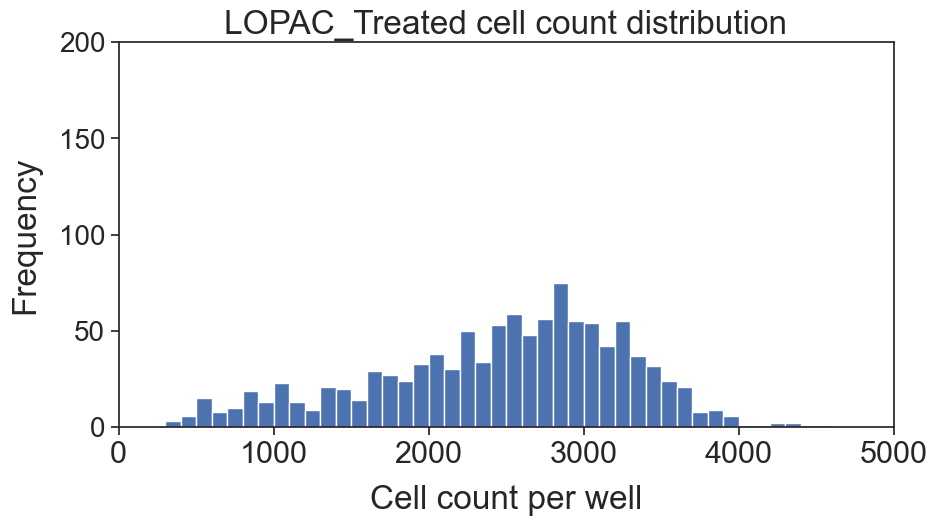

In [ ]:
"""Cell count distribution of Sample group"""

# set a flag for saving the figure, if needed.
save_fig = False

plt.figure(figsize=(10, 5))
sns.set(font_scale=2)
sns.set_style("ticks")
g = sns.histplot(
    data=df_Sample,
    x="Nuclei in confirmed total cell region - Number of Objects",
    binrange=(0.0, 5000),
    bins=50,
    kde=False,
    alpha=1
)  # binrange=(0.0, 0.015), 

# distance of label from x and y axes
g.xaxis.set_label_coords(0.5, -0.15)   
g.yaxis.set_label_coords(-0.10, 0.5)   

# Define the limits of x and y axes. Start with (0, 0) at the bottom left.
plt.xlim(0, 5000) 
plt.ylim(0, 200)

# Add a label to x and y axes and a title to the graph. Change the sizes,
# if needed.  
plt.xlabel('Cell count per well', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.title("LOPAC_Treated cell count distribution")

# Modify the values and size of ticks of y axis 
plt.yticks(fontsize=20)
# g.set(yticks=[5, 10, 15, 20, 25, 30, 35, 40])

if save_fig:

    # Define the export directory for the image.
    img_export_dir = (
    r"YOUR_EXPORT_DIRECTORY_HERE"
    )

    # Save the image in .svg or .png format. 
    plt.savefig(
        fname=img_export_dir + "/LOPAC_Treated cell count distribution.png",
        bbox_inches='tight',
        pad_inches=0.5
    )       
    plt.close()
    
else:
    plt.show()